# Análisis de Figuras Geométricas

Este cuaderno realiza las siguientes tareas:
1. **Carga de imágenes:** Permite alternar entre `fuente1` y `fuente2`.
2. **Binarización:** Uso de `cv2.threshold()` para segmentar las figuras.
3. **Detección de contornos:** Uso de `cv2.findContours()`.
4. **Propiedades Geométricas:** Cálculo de Área, Perímetro y Centroide (momentos).
5. **Etiquetado:** Dibujar contornos y mostrar métricas sobre la imagen.
6. **Clasificación:** Identificación de figuras (Triángulo, Cuadrado/Rectángulo, Círculo) mediante `cv2.approxPolyDP()`.

Recuerda seguir los pasos del README.md para configurar el entorno de python y el kernel de jupyter

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Configuración de visualización para matplotlib
%matplotlib inline

## 1. Cargar la imagen
Cambia la variable `image_source` para alternar entre 'fuente1' y 'fuente2'.

In [35]:
# Configuración de la fuente de imagen
fuente1 = '../media/fuente1.png'
fuente2 = '../media/fuente2.png'

def getImage(image_path):
    if not os.path.exists(image_path):
        print(f"Error: No se encontró el archivo en {image_path}")
    else:
        # Cargar imagen original
        image = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        return (img_rgb, img_gray)

## 2. Binarización
Convertimos la imagen a blanco y negro para facilitar la detección de contornos.

Tambien se podria saturar la imagen para mejorar la deteccion

In [36]:
def getBinaryImage(img_gray):
    # Aplicar umbral (Threshold)
    # Se usa THRESH_BINARY_INV porque usualmente las figuras son oscuras sobre fondo claro
    _, img_bin = cv2.threshold(img_gray, 200, 255, cv2.THRESH_BINARY_INV)

    # Si la mayoría de la imagen es blanca después de la inversión, aplicamos NOT
    if np.mean(img_bin) > 127:
        img_bin = cv2.bitwise_not(img_bin)

    return img_bin

## 3. Análisis de Contornos y Clasificación
Defininimos la funcion donde detectamos las figuras, calculamos sus propiedades y las clasificamos según sus vértices.

In [37]:
def getContoursImage(img_rgb, img_gray, img_bin):
    # Detectar contornos
    contours, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Copia de la imagen original para dibujar resultados
    img_result = img_rgb.copy()

    print(f"Se detectaron {len(contours)} contornos.\n")

    for i, cnt in enumerate(contours):
        # --- 1. Propiedades Básicas ---
        area = cv2.contourArea(cnt)
        
        # Filtrar ruidos o motas pequeñas
        if area < 500:
            continue
            
        perimeter = cv2.arcLength(cnt, True)
        
        # --- 2. Centroide (Momentos) ---
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = 0, 0
            
        # --- 3. Clasificación por Vértices (approxPolyDP) ---
        # Epsilon es la precisión de la aproximación
        epsilon = 0.02 * perimeter
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        vertices = len(approx)
        
        if vertices == 3:
            shape = "Triangulo"
        elif vertices == 4:
            # Se puede refinar a Cuadrado vs Rectángulo comparando lados, 
            # pero aquí lo agrupamos como pedido.
            shape = "Cuadrilatero"
        elif vertices > 4:
            shape = "Circulo (aprox)"
        else:
            shape = f"Poligono ({vertices} v)"
            
        # --- 4. Dibujar y Etiquetar ---
        # Dibujar contorno en verde
        cv2.drawContours(img_result, [cnt], -1, (0, 255, 0), 3)
        # Dibujar punto en el centroide
        cv2.circle(img_result, (cx, cy), 7, (255, 0, 0), -1)
        
        # Texto informativo
        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(img_result, f"{shape}", (cx - 50, cy - 50), font, 0.7, (255, 0, 0), 2)
        cv2.putText(img_result, f"Area: {int(area)}", (cx - 50, cy - 30), font, 0.5, (0, 0, 0), 1)
        cv2.putText(img_result, f"Perim: {int(perimeter)}", (cx - 50, cy - 10), font, 0.5, (0, 0, 0), 1)
        cv2.putText(img_result, f"Centro: ({cx},{cy})", (cx - 50, cy + 10), font, 0.5, (0, 0, 0), 1)
    
    return img_result

Se detectaron 204 contornos.



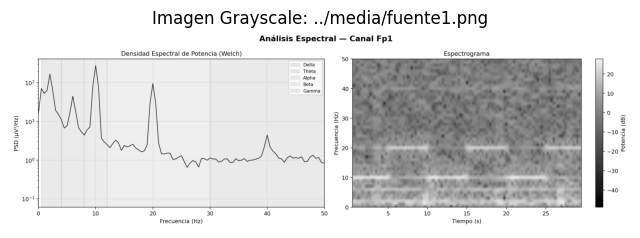

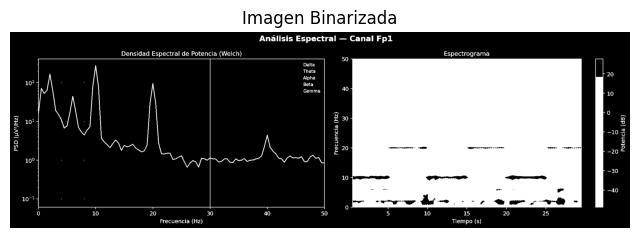

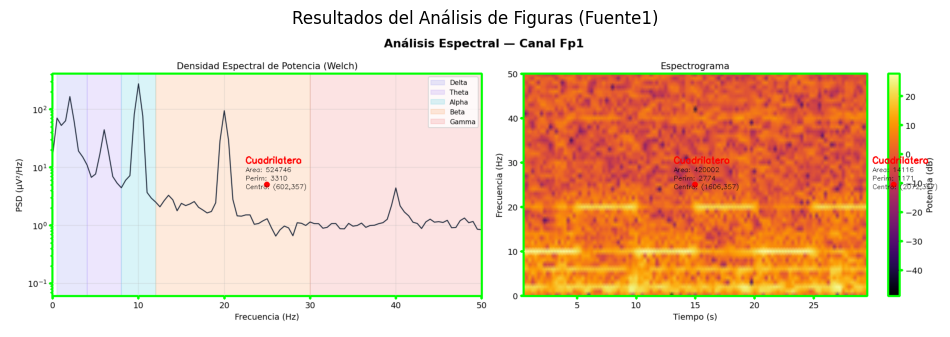

In [38]:
# fuente1
fuente1_rgb, fuente1_gray = getImage(fuente1)
fuente1_bin = getBinaryImage(fuente1_gray)
fuente1_result = getContoursImage(fuente1_rgb, fuente1_gray, fuente1_bin)

# Mostrar grayscale
plt.figure(figsize=(8, 5))
# Restaurar mapa de color
plt.imshow(cv2.cvtColor(fuente1_gray, cv2.COLOR_BGR2RGB))
plt.title(f'Imagen Grayscale: {fuente1}')
plt.axis('off')
plt.show()

# Mostrar binarizacion
plt.figure(figsize=(8, 5))
plt.imshow(fuente1_bin, cmap='gray')
plt.title('Imagen Binarizada')
plt.axis('off')
plt.show()

# Mostrar resultado final
plt.figure(figsize=(12, 8))
plt.imshow(fuente1_result)
plt.title('Resultados del Análisis de Figuras (Fuente1)')
plt.axis('off')
plt.show()

Se detectaron 559 contornos.



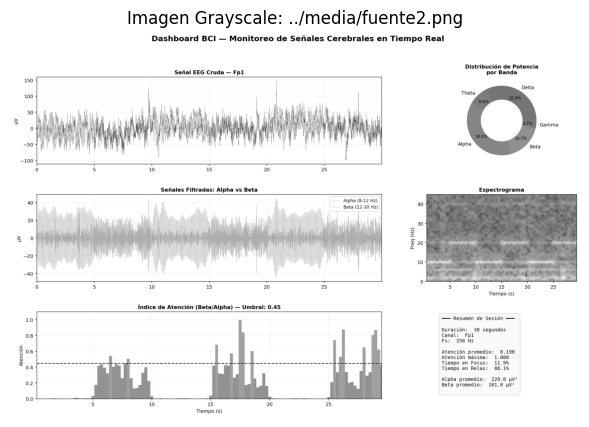

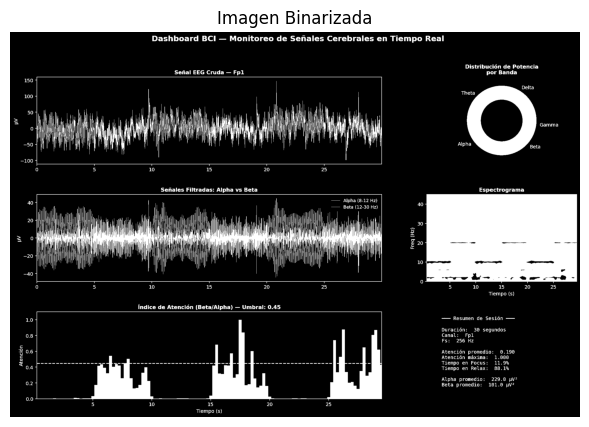

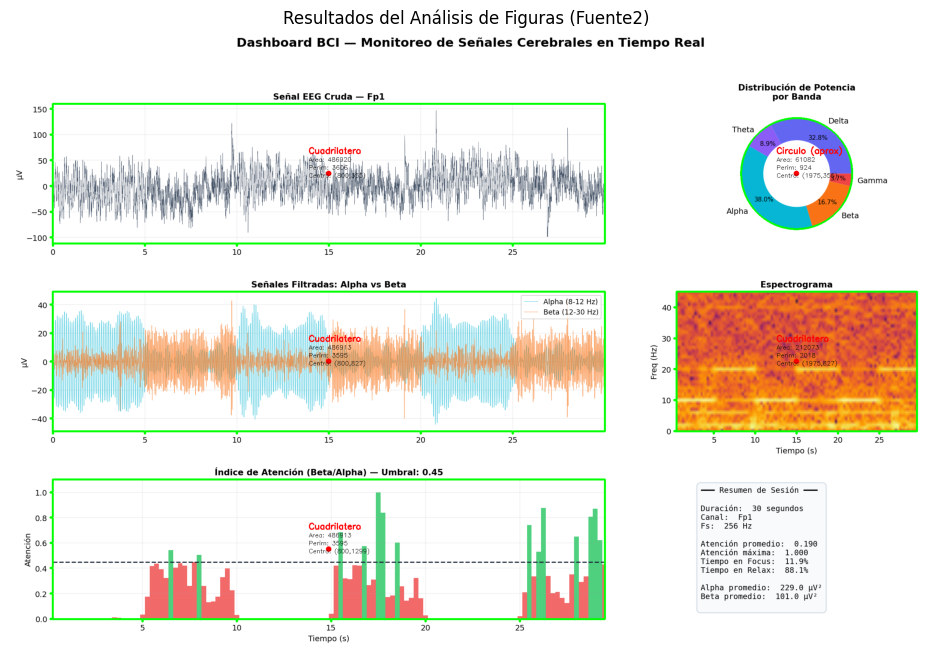

In [39]:
# fuente2
fuente2_rgb, fuente2_gray = getImage(fuente2)
fuente2_bin = getBinaryImage(fuente2_gray)
fuente2_result = getContoursImage(fuente2_rgb, fuente2_gray, fuente2_bin)

# Mostrar grayscale
plt.figure(figsize=(8, 5))
# Restaurar mapa de color
plt.imshow(cv2.cvtColor(fuente2_gray, cv2.COLOR_BGR2RGB))
plt.title(f'Imagen Grayscale: {fuente2}')
plt.axis('off')
plt.show()

# Mostrar binarizacion
plt.figure(figsize=(8, 5))
plt.imshow(fuente2_bin, cmap='gray')
plt.title('Imagen Binarizada')
plt.axis('off')
plt.show()

# Mostrar resultado final
plt.figure(figsize=(12, 8))
plt.imshow(fuente2_result)
plt.title('Resultados del Análisis de Figuras (Fuente2)')
plt.axis('off')
plt.show()